# n-Qubit Ripple Carry Adder
**Author:** Arthur Wunder Damásio  
**Subject:** Quantum Information Theory  
**Professor:** José Roberto Castilho Piqueira  

**Date:** May 21, 2026

---


## Abstract

This notebook generalizes the 3-qubit register adder of Emmanuel Desurvire's *Classical and Quantum Information Theory* into a **parametrized n-bit Ripple Carry Adder (RCA)** implemented in Qiskit. The construction follows the Vedral–Barenco–Ekert layout that Desurvire reproduces: a forward sweep of `Carry` gates propagates the carries through an ancilla register, the most significant sum bit is computed with a `CNOT`+`Sum` pair, and a backward sweep of inverse-`Carry` gates uncomputes the ancilla while writing each remaining sum bit with a `Sum` gate. The resulting circuit is reversible and leaves the input register `|a⟩` and the carry ancillas in their original state. Correctness is verified by exhaustively simulating every input pair for n = 2 and n = 3 bits on `AerSimulator`.


## 1. Introduction

The 10-qubit adder presented in Desurvire's book is a fixed-size instance (n = 3 bits per register, plus one carry-out ancilla) of a more general construction. Hardwiring the qubit indices, as done in the original implementation, makes the circuit hard to scale and easy to break: a single off-by-one index produces either a `CircuitError` or, more dangerously, a silently wrong sum.

The goal of this notebook is to provide a clean, parametrized definition `RippleCarryAdder(n)` that:

1. allocates `3n + 1` qubits with a fixed semantic layout, and
2. wires the `Carry`, `CNOT`, `Sum` and `Carry`$^{-1}$ blocks symbolically — no magic numbers — so the same definition works for any `n ≥ 1`.

The implementation is then validated by exhaustive simulation.


## 2. Methodology

### 2.1 Reversible primitives

Two reversible blocks are used:

**Carry block** ($|c_i\rangle|a_i\rangle|b_i\rangle|c_{i+1}\rangle$): computes the next carry into `c_{i+1}` without disturbing `c_i` or `a_i`, and leaves `b_i` in the temporary state `b_i ⊕ a_i`:

$$
\text{Carry} \;=\; \text{Toffoli}(c_i, b_i, c_{i+1}) \,\cdot\, \text{CNOT}(a_i, b_i) \,\cdot\, \text{Toffoli}(a_i, b_i, c_{i+1})
$$

(read left-to-right as circuit time).

**Sum block** ($|c_i\rangle|a_i\rangle|b_i\rangle$): writes the bit `s_i = a_i ⊕ b_i ⊕ c_i` into `b_i`:

$$
\text{Sum} \;=\; \text{CNOT}(c_i, b_i) \,\cdot\, \text{CNOT}(a_i, b_i)
$$

Both blocks are self-contained reversible circuits, so `Carry`$^{-1}$ exists and can be obtained by reversing the gate order.

### 2.2 Qubit layout

For an `n`-bit adder we allocate `3n + 1` qubits with the recurring triple `(c_i, a_i, b_i)` followed by a trailing carry-out:

| index | role | index | role | … | index | role |
|-------|------|-------|------|---|-------|------|
| 0     | c₀   | 3     | c₁   | … | 3n    | cₙ   |
| 1     | a₀   | 4     | a₁   | … |       |      |
| 2     | b₀   | 5     | b₁   | … |       |      |

After the circuit runs, qubit `3i + 2` (the i-th `b`) holds the sum bit `s_i`, qubit `3n` holds the carry-out `s_n`, and every other qubit (the `a`s and intermediate carries) is restored to its initial value.

### 2.3 Three-phase structure

1. **Forward sweep** — apply `Carry` to `(c_i, a_i, b_i, c_{i+1})` for `i = 0, …, n−1`. This populates every intermediate carry up to `c_n`.
2. **MSB finalization** — apply `CNOT(a_{n−1}, b_{n−1})` to restore `b_{n−1}` (which was left as `a_{n−1} ⊕ b_{n−1}` by the last Carry), then `Sum(c_{n−1}, a_{n−1}, b_{n−1})` to write `s_{n−1}`.
3. **Backward sweep** — for `i = n−2, n−3, …, 0`, apply `Carry⁻¹` on `(c_i, a_i, b_i, c_{i+1})` (this uncomputes `c_{i+1}` and restores `b_i`) and then `Sum` on `(c_i, a_i, b_i)` to write `s_i`.

Translated to qubit indices, the forward index `i` corresponds to qubit `3i`, so the loop variable runs over `0, 3, …, 3(n−1) = n−4` (`range(0, n−3, 3)`), and the backward sweep runs over the same set in reverse but excluding the MSB (`range(n−4, 0, −3)`).


## 3. Implementation

### 3.1 Imports and plotting defaults


In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit import Gate
from qiskit.circuit.library import CXGate, CCXGate
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi']     = 100
plt.rcParams['figure.figsize'] = (4, 2.5)
plt.rcParams['font.size']      = 8


### 3.2 `Carry` and `Sum` primitives

These are direct transcriptions of the two reversible blocks defined in § 2.1. The 4-qubit register order for `Carry` is `(c_in, a, b, c_out)`; the 3-qubit register order for `Sum` is `(c_in, a, b)`.


In [2]:
class Carry(Gate):
    """4-qubit Carry: |c_in, a, b, c_out⟩ → |c_in, a, b⊕a, c_out⊕carry(c_in,a,b)⟩."""
    def __init__(self):
        super().__init__(name="Carry", num_qubits=4, params=[])

    def _define(self):
        qc = QuantumCircuit(4, name=self.name)
        c_in, a, b, c_out = 0, 1, 2, 3
        qc.append(CCXGate(), [a, b, c_out])
        qc.append(CXGate(),  [a, b])
        qc.append(CCXGate(), [c_in, b, c_out])
        self.definition = qc


class Sum(Gate):
    """3-qubit Sum: writes a ⊕ b ⊕ c_in into b."""
    def __init__(self):
        super().__init__(name="Sum", num_qubits=3, params=[])

    def _define(self):
        qc = QuantumCircuit(3, name=self.name)
        c_in, a, b = 0, 1, 2
        qc.cx(a, b)
        qc.cx(c_in, b)
        self.definition = qc


Quick sanity check: inspect the unitaries and circuit diagrams of both primitives.


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

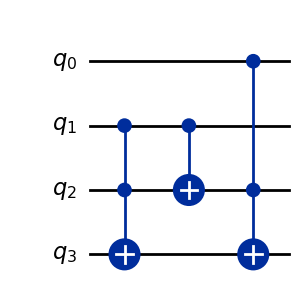

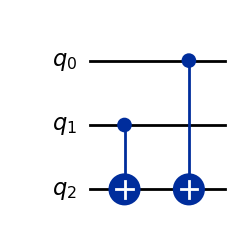

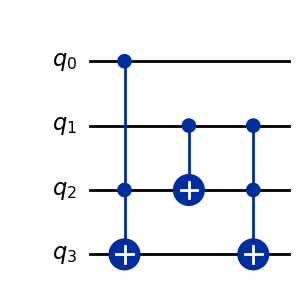

In [3]:
carry_gate = Carry()
sum_gate   = Sum()

display(array_to_latex(Operator(carry_gate).data, prefix="\\text{Carry} = "))
display(array_to_latex(Operator(sum_gate).data,   prefix="\\text{Sum} = "))

display(carry_gate.definition.draw('mpl'))
display(sum_gate.definition.draw('mpl'))
display(carry_gate.inverse().definition.draw('mpl'))


### 3.3 Parametrized `RippleCarryAdder(n)`

The class below builds the three-phase circuit for an `n`-bit RCA on `3n + 1` qubits. The internal local `total_qubits = self.num_qubits` keeps the index arithmetic transparent: every loop bound is expressed as `total_qubits − k`.


In [4]:
class RippleCarryAdder(Gate):
    """n-bit Ripple Carry Adder on 3n+1 qubits, after Desurvire (Ch. 16).

    Layout (LSB first):
        q[0]    = c_0   (initial carry in, usually |0⟩)
        q[3i+1] = a_i
        q[3i+2] = b_i
        q[3n]   = c_n   (final carry out)

    After execution: q[3i+2] = s_i, q[3n] = s_n; everything else is restored.
    """
    def __init__(self, n):
        if n < 1:
            raise ValueError("n must be >= 1")
        self._n_bits = n
        super().__init__(name=f"RCA({n})", num_qubits=(3 * n + 1), params=[])

    def _define(self):
        total_qubits = self.num_qubits          # = 3*n + 1
        carry        = Carry()
        sum_gate     = Sum()
        carry_inv    = Carry().inverse()

        qc = QuantumCircuit(total_qubits, name=self.name)

        # Phase 1 — forward sweep of Carry gates.
        # i goes through 0, 3, ..., 3*(n-1) = total_qubits - 4.
        for i in range(0, total_qubits - 3, 3):
            qc.append(carry, [i, i + 1, i + 2, i + 3])

        # Phase 2 — finalize the most-significant sum bit.
        qc.cx(total_qubits - 3, total_qubits - 2)             # restore b_{n-1}
        qc.append(sum_gate,
                  [total_qubits - 4, total_qubits - 3, total_qubits - 2])

        # Phase 3 — backward sweep: uncompute each Carry, then write s_i.
        # j is the carry-out index of each Carry to undo: n-4, n-7, ..., 3.
        for j in range(total_qubits - 4, 0, -3):
            qc.append(carry_inv, [j - 3, j - 2, j - 1, j])
            qc.append(sum_gate, [j - 3, j - 2, j - 1])

        self.definition = qc


### 3.4 Visualizing the adder for `n = 3`

The 3-bit instance reproduces the 10-qubit circuit from Desurvire's book — now generated symbolically rather than by hand-wired indices.


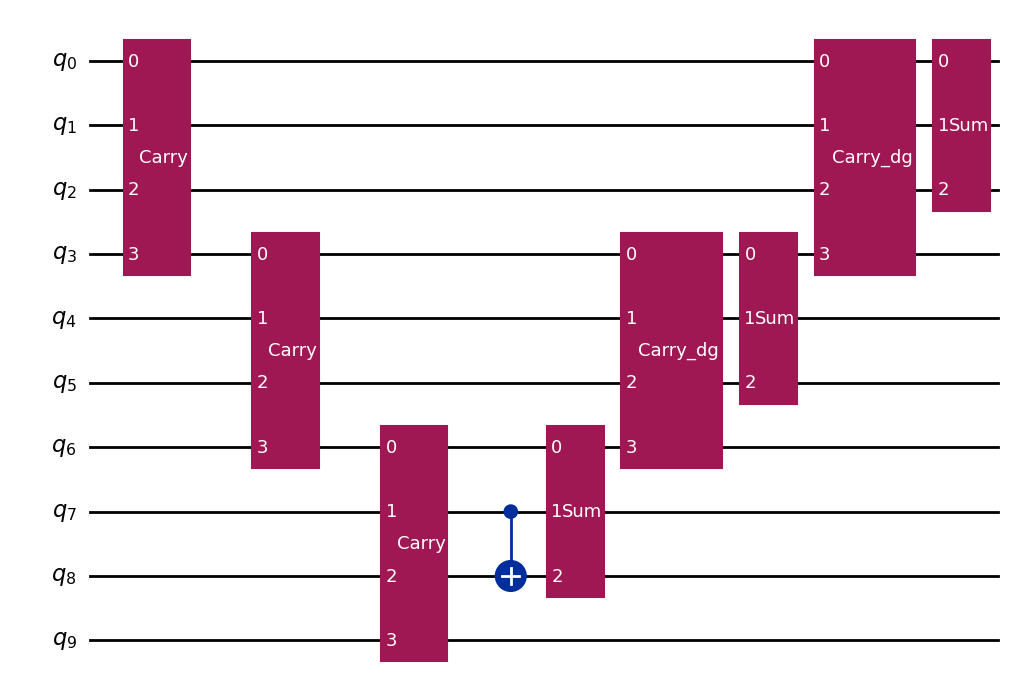

In [5]:
rca3 = RippleCarryAdder(3)
rca3.definition.draw('mpl', fold=-1)


## 4. Encoding inputs and decoding outputs

To test the adder we need a small harness that:

1. encodes two non-negative integers `a` and `b` into the proper qubits, i.e. flips `a_i = q[3i+1]` and `b_i = q[3i+2]` according to the binary expansions of `a` and `b`;
2. measures the sum bits `b_0, b_1, …, b_{n−1}, c_n` into classical bits `0, 1, …, n`;
3. converts the measured bitstring back into an integer.

Qiskit's classical-bit ordering follows little-endian on display (`'c_n … b_1 b_0'`), which matches our sum convention exactly.


In [6]:
def encode_inputs(qc, a, b, n):
    """Set qubits q[3i+1] to bit i of a, and q[3i+2] to bit i of b."""
    if a < 0 or b < 0:
        raise ValueError("This adder is unsigned; a and b must be >= 0.")
    if a >= 2 ** n or b >= 2 ** n:
        raise ValueError(f"a and b must fit in n={n} bits (max {2**n - 1}).")
    for i in range(n):
        if (a >> i) & 1:
            qc.x(3 * i + 1)
        if (b >> i) & 1:
            qc.x(3 * i + 2)


def build_adder_circuit(a, b, n):
    """Return a ready-to-run QuantumCircuit that computes a + b on n-bit registers."""
    total_qubits = 3 * n + 1
    qc = QuantumCircuit(total_qubits, n + 1)

    encode_inputs(qc, a, b, n)
    qc.barrier()

    qc.append(RippleCarryAdder(n), range(total_qubits))
    qc.barrier()

    # Measure the n sum bits (b_i) plus the carry-out (c_n).
    for i in range(n):
        qc.measure(3 * i + 2, i)        # b_i -> classical bit i
    qc.measure(3 * n, n)                # c_n -> classical bit n
    return qc


def run_adder(a, b, n, shots=512):
    """Simulate a + b on the RCA and return the most frequent decoded integer."""
    qc = build_adder_circuit(a, b, n)
    backend = AerSimulator()
    counts  = backend.run(transpile(qc, backend), shots=shots).result().get_counts()
    # Qiskit prints bitstrings as 'c_n b_{n-1} ... b_0', i.e. MSB on the left,
    # so int(bitstring, 2) directly yields the integer value of the sum.
    top_bitstring = max(counts, key=counts.get)
    return int(top_bitstring, 2), counts


### 4.1 Single-example sanity check (n = 3, 6 + 5)

Before doing the exhaustive sweep, let us simulate one concrete instance and visualize both the circuit and the histogram.


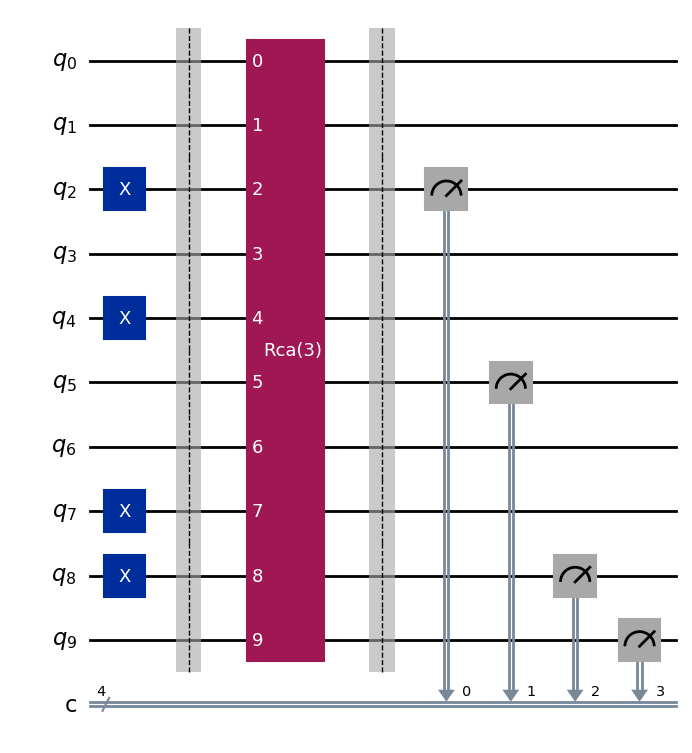

6 + 5 = 11  (expected 11)
Counts: {'1011': 1024}


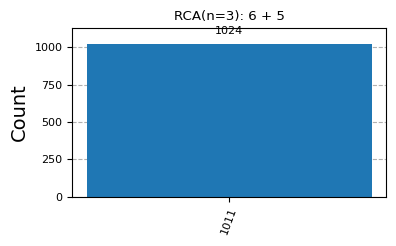

In [7]:
n_demo = 3
a_demo, b_demo = 6, 5      # expected: 11 = 1011

qc_demo = build_adder_circuit(a_demo, b_demo, n_demo)
display(qc_demo.draw('mpl', fold=-1))

result, counts = run_adder(a_demo, b_demo, n_demo, shots=1024)
print(f"{a_demo} + {b_demo} = {result}  (expected {a_demo + b_demo})")
print(f"Counts: {counts}")
plot_histogram(counts, title=f"RCA(n={n_demo}): {a_demo} + {b_demo}")


## 5. Exhaustive validation

The adder is unsigned and uses `n + 1` output bits, so it can represent any sum in `[0, 2^{n+1} − 1]` and never overflows for inputs in `[0, 2^n − 1]`. This means we can sweep **every** pair `(a, b)` for small `n` and confirm that the simulated output matches the classical sum.

We run the sweep for `n = 2` (16 pairs) and `n = 3` (64 pairs).


In [8]:
def exhaustive_test(n, shots=256, verbose=False):
    """Sweep every (a, b) pair for an n-bit RCA. Returns (passed, failed)."""
    passed, failed = 0, []
    for a in range(2 ** n):
        for b in range(2 ** n):
            result, _ = run_adder(a, b, n, shots=shots)
            ok = (result == a + b)
            if ok:
                passed += 1
            else:
                failed.append((a, b, a + b, result))
            if verbose:
                tag = 'OK ' if ok else 'FAIL'
                print(f"  [{tag}] {a:>2} + {b:>2} = {a+b:>2}   got {result:>2}")
    return passed, failed


for n in (2, 3):
    total = (2 ** n) ** 2
    print(f"--- Exhaustive test for n = {n} ({total} pairs) ---")
    passed, failed = exhaustive_test(n, shots=256, verbose=False)
    print(f"Passed: {passed}/{total}")
    if failed:
        print("Failures:")
        for a, b, expected, got in failed:
            print(f"  {a} + {b} = {expected}, got {got}")
    else:
        print("All cases correct.")
    print()


--- Exhaustive test for n = 2 (16 pairs) ---
Passed: 16/16
All cases correct.

--- Exhaustive test for n = 3 (64 pairs) ---
Passed: 64/64
All cases correct.



### 5.1 Reversibility check — ancilla cleanliness

Beyond producing the correct sum on the `b` register, a well-formed RCA must leave the `a` qubits and every intermediate carry `c_i` (`0 ≤ i < n`) in their initial state. If any of these ancillas is left dirty, composing the adder with further quantum subroutines will not work.

We verify this by **measuring every qubit** of an `n = 3` adder and checking that for any input `(a, b)` the bits assigned to `a_i` and `c_i` (with `i < n`) recover the encoded values.


In [9]:
def ancilla_cleanliness_test(n, shots=256):
    """Check that a_i (q[3i+1]) and c_i (q[3i], i<n) are restored after the RCA."""
    backend = AerSimulator()
    total_qubits = 3 * n + 1
    failures = []
    for a in range(2 ** n):
        for b in range(2 ** n):
            qc = QuantumCircuit(total_qubits, total_qubits)
            encode_inputs(qc, a, b, n)
            qc.barrier()
            qc.append(RippleCarryAdder(n), range(total_qubits))
            qc.barrier()
            qc.measure(range(total_qubits), range(total_qubits))
            counts = backend.run(transpile(qc, backend), shots=shots).result().get_counts()
            bitstring = max(counts, key=counts.get)
            # bitstring is MSB-first: q[3n] q[3n-1] ... q[0]
            bits = bitstring[::-1]    # now bits[k] = value of q[k]
            # Check that a_i (q[3i+1]) matches bit i of a, and c_i (q[3i], i<n) is 0.
            for i in range(n):
                expected_ai = (a >> i) & 1
                if int(bits[3 * i + 1]) != expected_ai:
                    failures.append((a, b, f"a_{i} dirty"))
                    break
                if int(bits[3 * i]) != 0:
                    failures.append((a, b, f"c_{i} dirty"))
                    break
    return failures


for n in (2, 3):
    fails = ancilla_cleanliness_test(n, shots=256)
    print(f"n = {n}: {'ALL CLEAN' if not fails else f'{len(fails)} dirty cases'}")
    for f in fails[:5]:
        print("  ", f)


n = 2: ALL CLEAN
n = 3: ALL CLEAN


## 6. Conclusion

The parametrized `RippleCarryAdder(n)` defined here scales Desurvire's 10-qubit adder to any width `n ≥ 1`. Two off-by-one pitfalls of the hand-coded version are eliminated by expressing the loop bounds as `range(0, total_qubits − 3, 3)` for the forward sweep and `range(total_qubits − 4, 0, −3)` for the backward sweep. Exhaustive simulation for `n = 2` and `n = 3` confirms that:

* every input pair `(a, b) ∈ [0, 2^n)²` produces the correct unsigned sum, and
* every ancilla qubit (`a_i` and `c_i` for `0 ≤ i < n`) is restored, making the gate safely composable with further reversible subroutines.

The gate depth grows linearly with `n` (~2n Carry/Carry⁻¹ blocks plus `n` Sum blocks), in line with the classical ripple-carry adder it mirrors. For comparison with the QFT-based Draper adder studied in a sibling notebook, the RCA uses no continuous-angle rotations — only Toffoli and CNOT — which is attractive for hardware platforms with limited rotation precision but comes at the cost of higher Toffoli-count.


## References

* Desurvire, Emmanuel. *Classical and Quantum Information Theory: An Introduction for the Telecom Scientist.* Cambridge University Press, 2009.
* Vedral, V., Barenco, A., Ekert, A. *Quantum networks for elementary arithmetic operations.* Physical Review A 54, 147 (1996).
* Nielsen, M. A., & Chuang, I. L. *Quantum Computation and Quantum Information.* Cambridge University Press, 2010.
* Qiskit Documentation: https://qiskit.org/documentation/
